In [1]:
import numpy as np
import pandas as pd
import sys
import matplotlib.pyplot as plt
from scipy import integrate
sys.path.append('../')
from Scattering_Simulator import pairwise_method
from Scattering_Simulator import Read_PDB
from genetic_algorithm import curve_fitting as cf

## Plot the Results
The results of the simulation is compared to experimental data. The experimental SAXS scattering curves correspond to protein crystals at different concentrations of  monodentate modulators.

In [2]:
D_plus1 = np.loadtxt('../Data/PDB/Comparison/D_plus_scattering_PDB_txt_6gbz.txt', skiprows=1) 
D_plus2 = np.loadtxt('../Data/PDB/Comparison/D_plus_scattering_PDB_txt_7lii.txt', skiprows=1) 
D_plus3 = np.loadtxt('../Data/PDB/Comparison/D_plus_scattering_PDB_txt_2qzv.txt', skiprows=1) 
D_plus4 = np.loadtxt('../Data/PDB/Comparison/D_plus_scattering_PDB_txt_8ac6.txt', skiprows=1) 
crysol1 = np.loadtxt('../Data/PDB/Comparison/CRYSOL_scattering_PDB_txt_6gbz.txt', skiprows=1)[4:-56,:] 
crysol2 = np.loadtxt('../Data/PDB/Comparison/CRYSOL_scattering_PDB_txt_7lii.txt', skiprows=1)[4:-56,:] 
crysol3 = np.loadtxt('../Data/PDB/Comparison/CRYSOL_scattering_PDB_txt_2qzv.txt', skiprows=1)[4:-56,:] 
crysol4 = np.loadtxt('../Data/PDB/Comparison/CRYSOL_scattering_PDB_txt_8ac6.txt', skiprows=1)[4:-56,:] 
mcdfm1 = np.load('../Data/PDB/Comparison/mcdfm_6gbz_scattering.npy')[500:] 
mcdfm2 = np.load('../Data/PDB/Comparison/mcdfm_7lii_scattering.npy')[500:] 
mcdfm3 = np.load('../Data/PDB/Comparison/mcdfm_2qzv_scattering.npy')[500:] 
mcdfm4 = np.load('../Data/PDB/Comparison/mcdfm_8ac6_scattering.npy')[500:] 


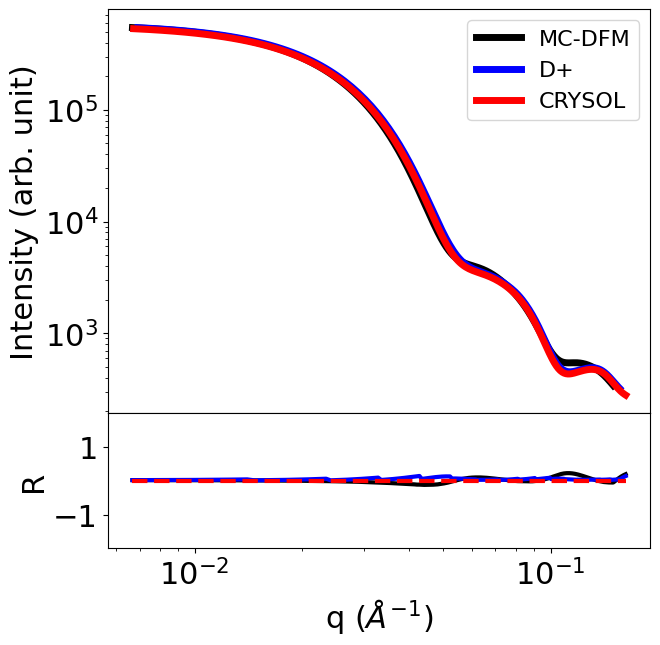

In [5]:
plt.rcParams.update({'font.size': 22})
fig, ax = plt.subplots(figsize=(7,7), ncols = 1, nrows=2,  gridspec_kw={'height_ratios': [3, 1]})
mcdfm_plot = np.hstack((mcdfm1[:,0].reshape(-1,1), (mcdfm1[:,1]*0.2e0).reshape(-1,1)))
dplus_plot = np.hstack(((D_plus1[10:-550,0]/10).reshape(-1,1), (D_plus1[10:-550,1]*1.03e-5).reshape(-1,1)))
crysol_plot = np.hstack((crysol1[5:,0].reshape(-1,1), (crysol1[5:,1]*1.2e-5).reshape(-1,1)))

ax[0].errorbar(mcdfm_plot[:,0], mcdfm_plot[:,1], linewidth = 5, label = 'MC-DFM', color ='k')
ax[0].errorbar(dplus_plot[:,0], dplus_plot[:,1], linewidth = 5, label = 'D+', color ='blue')
ax[0].errorbar(crysol_plot[:,0], crysol_plot[:,1], linewidth = 5, label = 'CRYSOL', color ='red')
ax[0].set_yscale('log')
ax[0].set_xscale('log')
ax[0].set_ylabel('Intensity (arb. unit)')
#ax[0].grid()
ax[0].legend(fontsize=16)
plt.subplots_adjust(hspace=0)


mcdfm_data = cf.convert_data(crysol_plot, mcdfm_plot)
dplus_data = cf.convert_data(crysol_plot, dplus_plot)

mcdfm_residual = (np.log(mcdfm_data[:,1]/crysol_plot[:,1]))
dplus_residual = (np.log(dplus_data[:,1]/crysol_plot[:,1]))

ax[1].plot(crysol_plot[:,0], mcdfm_residual, color ='k', linewidth = 3)
ax[1].plot(crysol_plot[:,0], dplus_residual, color ='blue', linewidth = 3)
ax[1].set_ylim([-2,2])
ax[1].set_yticks([-1,1])
ax[1].set_xscale('log')
ax[1].set_ylabel('R')
ax[1].hlines(0, np.min(crysol_plot[:,0]), np.max(crysol_plot[:,0]), color='red', linewidth=3, linestyle='--')
ax[1].set_xlabel('q ($\\AA^{-1}$)')
#plt.legend(fontsize=18)
#plt.savefig('../Images/Comparison_6gbz.png', dpi=300, bbox_inches="tight")
plt.show()

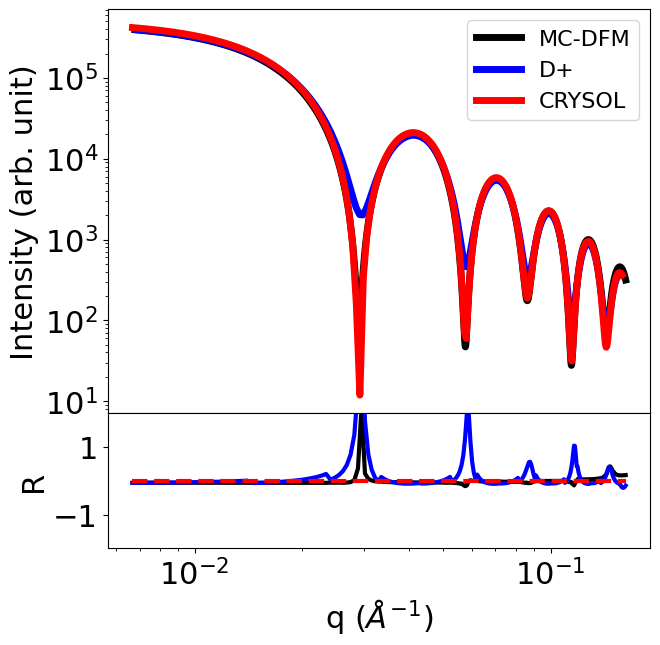

In [8]:
plt.rcParams.update({'font.size': 22})
fig, ax = plt.subplots(figsize=(7,7), ncols = 1, nrows=2,  gridspec_kw={'height_ratios': [3, 1]})
mcdfm_plot = np.hstack((mcdfm2[:-300,0].reshape(-1,1), (mcdfm2[:-300,1]*0.15e0).reshape(-1,1)))
dplus_plot = np.hstack(((D_plus2[10:-550,0]/10).reshape(-1,1), (D_plus2[10:-550,1]*1.15e-5).reshape(-1,1)))
crysol_plot = np.hstack((crysol2[5:,0].reshape(-1,1), (crysol2[5:,1]*1.2e-5).reshape(-1,1)))

ax[0].errorbar(mcdfm_plot[:,0], mcdfm_plot[:,1], linewidth = 5, label = 'MC-DFM', color ='k')
ax[0].errorbar(dplus_plot[:,0], dplus_plot[:,1], linewidth = 5, label = 'D+', color ='blue')
ax[0].errorbar(crysol_plot[:,0], crysol_plot[:,1], linewidth = 5, label = 'CRYSOL', color ='red')
ax[0].set_yscale('log')
ax[0].set_xscale('log')
ax[0].set_ylabel('Intensity (arb. unit)')
#ax[0].grid()
ax[0].legend(fontsize=16)
plt.subplots_adjust(hspace=0)


mcdfm_data = cf.convert_data(crysol_plot, mcdfm_plot)
dplus_data = cf.convert_data(crysol_plot, dplus_plot)

mcdfm_residual = (np.log(mcdfm_data[:,1]/crysol_plot[:,1]))
dplus_residual = (np.log(dplus_data[:,1]/crysol_plot[:,1]))

ax[1].plot(crysol_plot[:,0], mcdfm_residual, color ='k', linewidth = 3)
ax[1].plot(crysol_plot[:,0], dplus_residual, color ='blue', linewidth = 3)
ax[1].set_ylim([-2,2])
ax[1].set_yticks([-1,1])
ax[1].set_xscale('log')
ax[1].set_ylabel('R')
ax[1].hlines(0, np.min(crysol_plot[:,0]), np.max(crysol_plot[:,0]), color='red', linewidth=3, linestyle='--')
ax[1].set_xlabel('q ($\\AA^{-1}$)')
#plt.legend(fontsize=18)
#plt.savefig('../Images/Comparison_7lii.png', dpi=300, bbox_inches="tight")
plt.show()

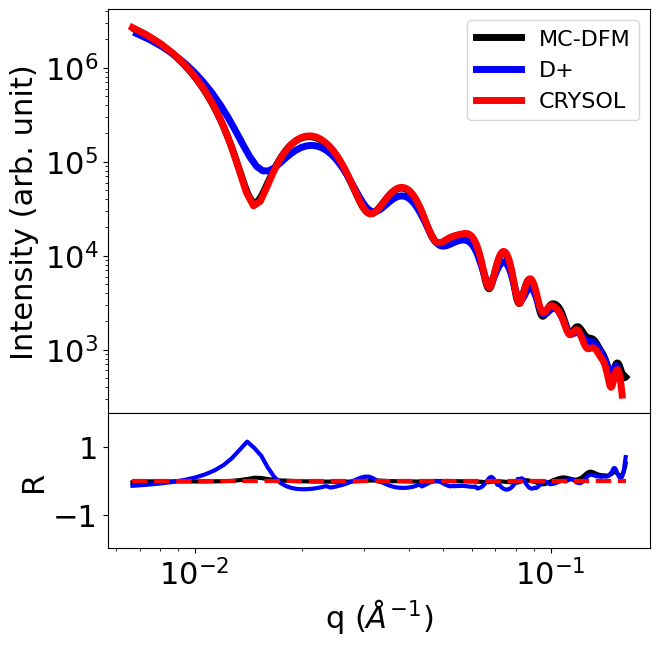

In [9]:
plt.rcParams.update({'font.size': 22})
fig, ax = plt.subplots(figsize=(7,7), ncols = 1, nrows=2,  gridspec_kw={'height_ratios': [3, 1]})
mcdfm_plot = np.hstack((mcdfm3[:-300,0].reshape(-1,1), (mcdfm3[:-300,1]*0.7e0).reshape(-1,1)))
dplus_plot = np.hstack(((D_plus3[10:-550,0]/10).reshape(-1,1), (D_plus3[10:-550,1]*1.05e-5).reshape(-1,1)))
crysol_plot = np.hstack((crysol3[5:,0].reshape(-1,1), (crysol3[5:,1]*1.2e-5).reshape(-1,1)))

ax[0].errorbar(mcdfm_plot[:,0], mcdfm_plot[:,1], linewidth = 5, label = 'MC-DFM', color ='k')
ax[0].errorbar(dplus_plot[:,0], dplus_plot[:,1], linewidth = 5, label = 'D+', color ='blue')
ax[0].errorbar(crysol_plot[:,0], crysol_plot[:,1], linewidth = 5, label = 'CRYSOL', color ='red')
ax[0].set_yscale('log')
ax[0].set_xscale('log')
ax[0].set_ylabel('Intensity (arb. unit)')
#ax[0].grid()
ax[0].legend(fontsize=16)
plt.subplots_adjust(hspace=0)


mcdfm_data = cf.convert_data(crysol_plot, mcdfm_plot)
dplus_data = cf.convert_data(crysol_plot, dplus_plot)

mcdfm_residual = (np.log(mcdfm_data[:,1]/crysol_plot[:,1]))
dplus_residual = (np.log(dplus_data[:,1]/crysol_plot[:,1]))

ax[1].plot(crysol_plot[:,0], mcdfm_residual, color ='k', linewidth = 3)
ax[1].plot(crysol_plot[:,0], dplus_residual, color ='blue', linewidth = 3)
ax[1].set_ylim([-2,2])
ax[1].set_yticks([-1,1])
ax[1].set_xscale('log')
ax[1].set_ylabel('R')
ax[1].hlines(0, np.min(crysol_plot[:,0]), np.max(crysol_plot[:,0]), color='red', linewidth=3, linestyle='--')
ax[1].set_xlabel('q ($\\AA^{-1}$)')
#plt.legend(fontsize=18)
#plt.savefig('../Images/Comparison_2qzv.png', dpi=300, bbox_inches="tight")
plt.show()

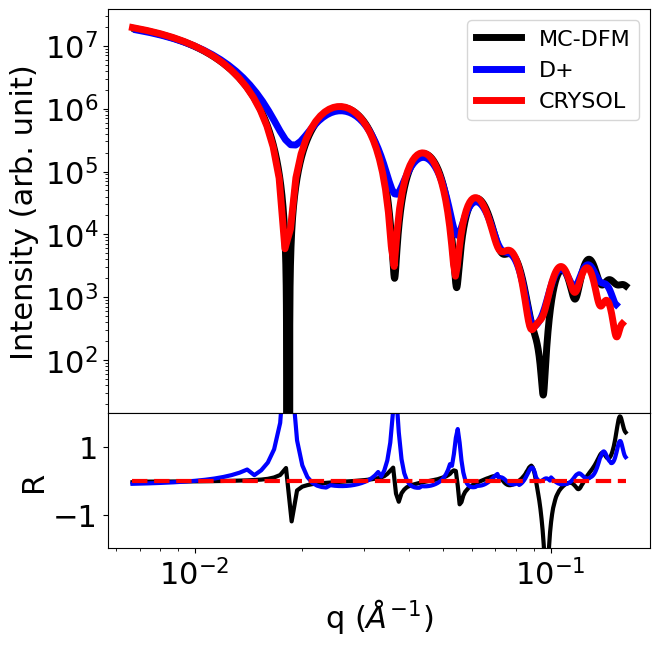

In [10]:
plt.rcParams.update({'font.size': 22})
fig, ax = plt.subplots(figsize=(7,7), ncols = 1, nrows=2,  gridspec_kw={'height_ratios': [3, 1]})
mcdfm_plot = np.hstack((mcdfm4[:-300,0].reshape(-1,1), (mcdfm4[:-300,1]*5.6e0).reshape(-1,1)))
dplus_plot = np.hstack(((D_plus4[10:-550,0]/10).reshape(-1,1), (D_plus4[10:-550,1]*1.13e-5).reshape(-1,1)))
crysol_plot = np.hstack((crysol4[5:,0].reshape(-1,1), (crysol4[5:,1]*1.2e-5).reshape(-1,1)))

ax[0].errorbar(mcdfm_plot[:,0], mcdfm_plot[:,1], linewidth = 5, label = 'MC-DFM', color ='k')
ax[0].errorbar(dplus_plot[:,0], dplus_plot[:,1], linewidth = 5, label = 'D+', color ='blue')
ax[0].errorbar(crysol_plot[:,0], crysol_plot[:,1], linewidth = 5, label = 'CRYSOL', color ='red')
ax[0].set_yscale('log')
ax[0].set_xscale('log')
ax[0].set_ylabel('Intensity (arb. unit)')
#ax[0].grid()
ax[0].legend(fontsize=16)
plt.subplots_adjust(hspace=0)


mcdfm_data = cf.convert_data(crysol_plot, mcdfm_plot)
dplus_data = cf.convert_data(crysol_plot, dplus_plot)

mcdfm_residual = (np.log(mcdfm_data[:,1]/crysol_plot[:,1]))
dplus_residual = (np.log(dplus_data[:,1]/crysol_plot[:,1]))

ax[1].plot(crysol_plot[:,0], mcdfm_residual, color ='k', linewidth = 3)
ax[1].plot(crysol_plot[:,0], dplus_residual, color ='blue', linewidth = 3)
ax[1].set_ylim([-2,2])
ax[1].set_yticks([-1,1])
ax[1].set_xscale('log')
ax[1].set_ylabel('R')
ax[1].hlines(0, np.min(crysol_plot[:,0]), np.max(crysol_plot[:,0]), color='red', linewidth=3, linestyle='--')
ax[1].set_xlabel('q ($\\AA^{-1}$)')
#plt.legend(fontsize=18)
#plt.savefig('../Images/Comparison_8ac6.png', dpi=300, bbox_inches="tight")
plt.show()

In [18]:
#crysol run with 20 maximum number of spherical harmonics, and 300 points with maxq of 0.2 inv ang

protein_size = np.array([86401]) #6gbz
time = np.array([1, 30, 17]) #MCDFM, D+, CRYSOL

protein_size_2 = np.array([127320]) #7lii
time_2 = np.array([1, 42, 37]) #MCDFM, D+, CRYSOL

protein_size_3 = np.array([355392]) #2qzv.pdb
time_3 = np.array([1, 116, 71]) #MCDFM, D+, CRYSOL

protein_size_4 = np.array([982380]) #8ac6.pdb
time_4 = np.array([1, 745, 557]) #MCDFM, D+, CRYSOL

atoms = np.array([86401, 127320, 355392, 982380])/1000
mcdfm_time = np.array([1,1,1,1])
dplus_time = np.array([30, 42, 116, 745])
crysol_time = np.array([17, 37, 71, 557])


In [19]:
coords = Read_PDB.load_pdb('../Data/PDB/6gbz.pdb')
coords.shape

(86401, 4)

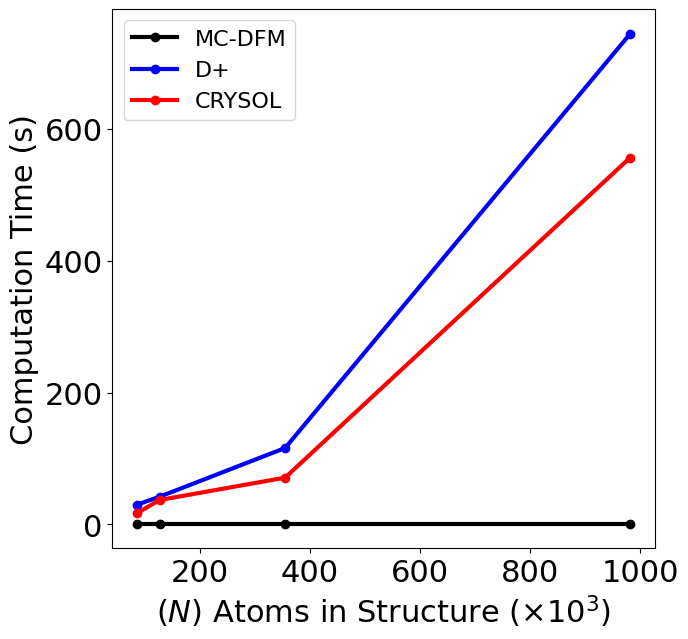

In [25]:
fig, ax = plt.subplots(figsize=(7,7))
plt.plot(atoms, mcdfm_time, '-o', label='MC-DFM', linewidth=3, color='k')
plt.plot(atoms, dplus_time, '-o', label='D+', linewidth=3, color ='blue')
plt.plot(atoms, crysol_time,'-o', label='CRYSOL', linewidth=3, color ='red')
plt.legend(fontsize=16)
plt.xlabel('($N$) Atoms in Structure $(\\times 10^{3})$')
plt.ylabel('Computation Time (s)')
#plt.savefig('../Images/comparison.png', dpi=600, bbox_inches="tight")